In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import sys
sys.path.append("..")

from plotting_tools import * 

In [ ]:
station = "S_M4"
timepoint = 0

station_file = f"infection_age_shedding_{timepoint}_{station}.csv"
df = pd.read_csv(station_file)

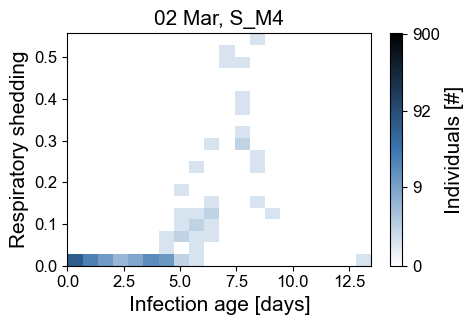

In [32]:
fig, ax = plt.subplots(figsize=(5, 3.5))

start_date = datetime(2020, 3, 2)
date = (start_date + timedelta(hours=int(timepoint))).strftime('%d %b')

custom_cmap_blue = mcolors.LinearSegmentedColormap.from_list('custom_blue', [colors['White'], colors['Blue'], colors['Black']])
norm = Log1pNorm(vmin=0, vmax=912) 

h = ax.hist2d(
    df.infection_age/24.,
    df.shedding,
    bins=20,
    cmap=custom_cmap_blue,
    norm=norm
)

cbar = fig.colorbar(h[3], ax=ax)
cbar.set_label('Individuals [#]')
n_ticks = 4
normed_positions = np.linspace(0, norm(900), n_ticks)
tick_values = [int(np.round(norm.inverse(p))) for p in normed_positions]
cbar.set_ticks(tick_values)
cbar.set_ticklabels([f"{tick}" for tick in tick_values])

ax.set_xlabel('Infection age [days]')
ax.set_ylabel('Respiratory shedding')

ax.set_title(f'{date}, {station}')

plt.tight_layout()
fig.savefig(f"infection_age_shedding_{date}_{station}", dpi=dpi)
plt.show()